<a href="https://colab.research.google.com/github/ID26S422/The-Feature-Matching-Project/blob/main/SuperGlue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/magicleap/SuperGluePretrainedNetwork.git

Cloning into 'SuperGluePretrainedNetwork'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 185 (delta 0), reused 0 (delta 0), pack-reused 184 (from 2)
Receiving objects: 100% (185/185), 118.85 MiB | 27.25 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import cv2
import torch
import getpass

print("PyTorch :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("OpenCV  :", cv2.__version__)
print("NumPy   :", np.__version__)
print("Matplotlib :", matplotlib.__version__)

PyTorch : 2.11.0+cpu
CUDA available : False
OpenCV  : 4.14.0
NumPy   : 2.1.3
Matplotlib : 3.10.0


In [3]:
!git clone https://github.com/ID26S422/The-Feature-Matching-Project.git

Cloning into 'The-Feature-Matching-Project'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 84 (delta 4), reused 9 (delta 2), pack-reused 71 (from 1)
Receiving objects: 100% (84/84), 146.16 MiB | 21.39 MiB/s, done.
Resolving deltas: 100% (26/26), done.


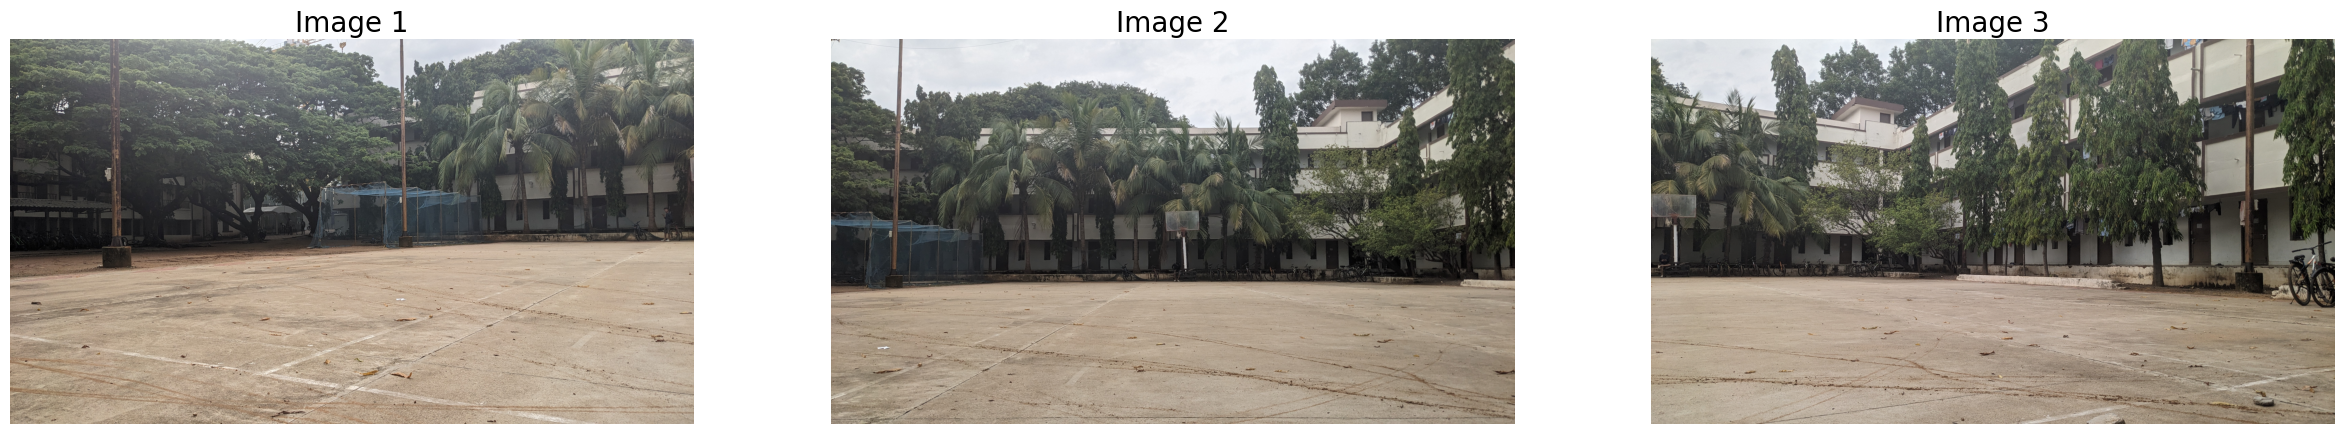

In [4]:
from PIL import Image

image1_path="/content/The-Feature-Matching-Project/images/Image1.jpg"
image2_path="/content/The-Feature-Matching-Project/images/Image2.jpg"
image3_path="/content/The-Feature-Matching-Project/images/Image3.jpg"

img1=np.array(Image.open(image1_path))
img2=np.array(Image.open(image2_path))
img3=np.array(Image.open(image3_path))

plt.figure(figsize=(30,10))

plt.subplot(1,3,1)
plt.imshow(img1)
plt.axis('off')
plt.title("Image 1", fontsize=20)

plt.subplot(1,3,2)
plt.imshow(img2)
plt.axis('off')
plt.title("Image 2", fontsize=20)

plt.subplot(1,3,3)
plt.imshow(img3)
plt.axis('off')
plt.title("Image 3", fontsize=20)

plt.show()

match_pairs accepts a folder with pair of images being given as text which directs it there, not images. so we create it below.

In [5]:
import os

#assignment repository
repo_dir = "/content/The-Feature-Matching-Project"

#image filenames in panorama order
image1 = "Image1.jpg"
image2 = "Image2.jpg"
image3 = "Image3.jpg"

# Create the pair file
pairs_file = os.path.join(repo_dir, "pairs.txt")

with open(pairs_file, "w") as f:
    f.write(f"{image1} {image2}\n")
    f.write(f"{image2} {image3}\n")

print("\nCreated pairs.txt:")
with open(pairs_file, "r") as f:
    print(f.read())


Created pairs.txt:
Image1.jpg Image2.jpg
Image2.jpg Image3.jpg



In [6]:
import subprocess

#SuperGlue repository
superglue_repo = "/content/SuperGluePretrainedNetwork"

#input images and pair file from your assignment repo
input_dir = os.path.join(repo_dir, "images")
pairs_file = os.path.join(repo_dir, "pairs.txt")

#where SuperGlue results will be saved
output_dir = os.path.join(repo_dir, "results", "superglue")
os.makedirs(output_dir, exist_ok=True)

#SuperGlue matching script
match_script = os.path.join(superglue_repo, "match_pairs.py")

#running superglue match_pairs on the images and considering parameters according to input images as recommended
#by readme file in superglue repo.
command = [
    "python",
    match_script,
    "--input_dir", input_dir,
    "--input_pairs", pairs_file,
    "--output_dir", output_dir,
    "--resize", "1600",
    "--superglue", "outdoor",
    "--max_keypoints", "2048",
    "--nms_radius", "3",
    "--resize_float",
    "--viz"
]

subprocess.run(command, check=True)

print("\nResults:")
for filename in os.listdir(output_dir):
    print(filename)


Results:
Image2_Image3_matches.npz
PXL_20260824_111109349.MP_PXL_20260824_111123451_matches.png
Image1_Image2_matches.npz
PXL_20260824_111109349.MP_PXL_20260824_111123451_matches.npz
PXL_20260824_111123451_PXL_20260824_111129452_matches.npz
Image2_Image3_matches.png
Image1_Image2_matches.png
PXL_20260824_111123451_PXL_20260824_111129452_matches.png


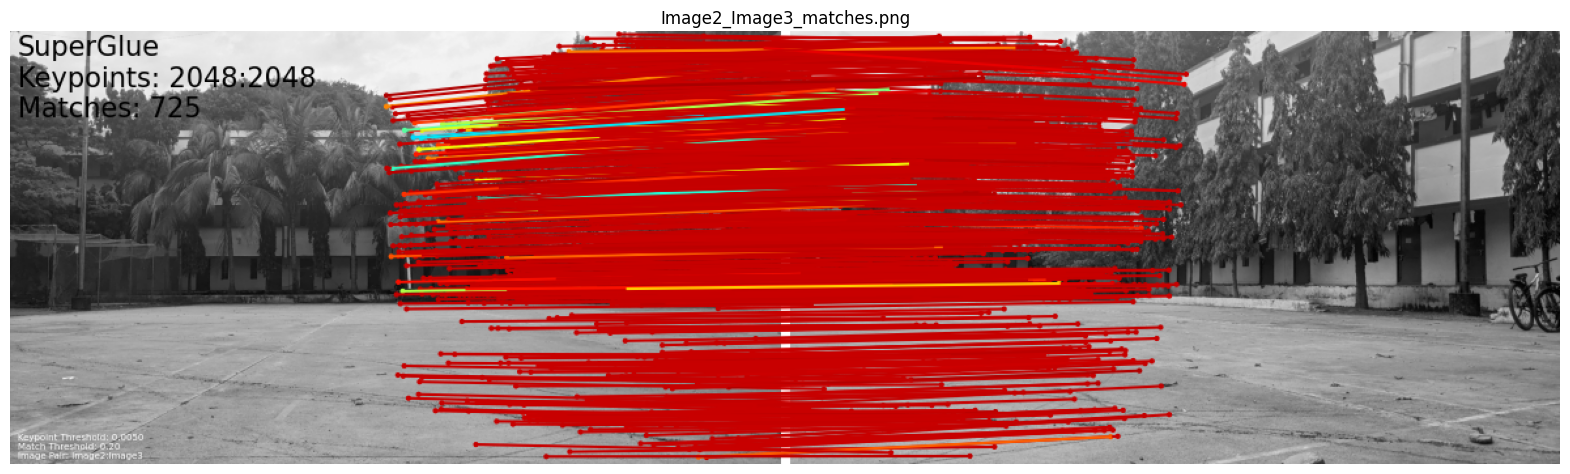

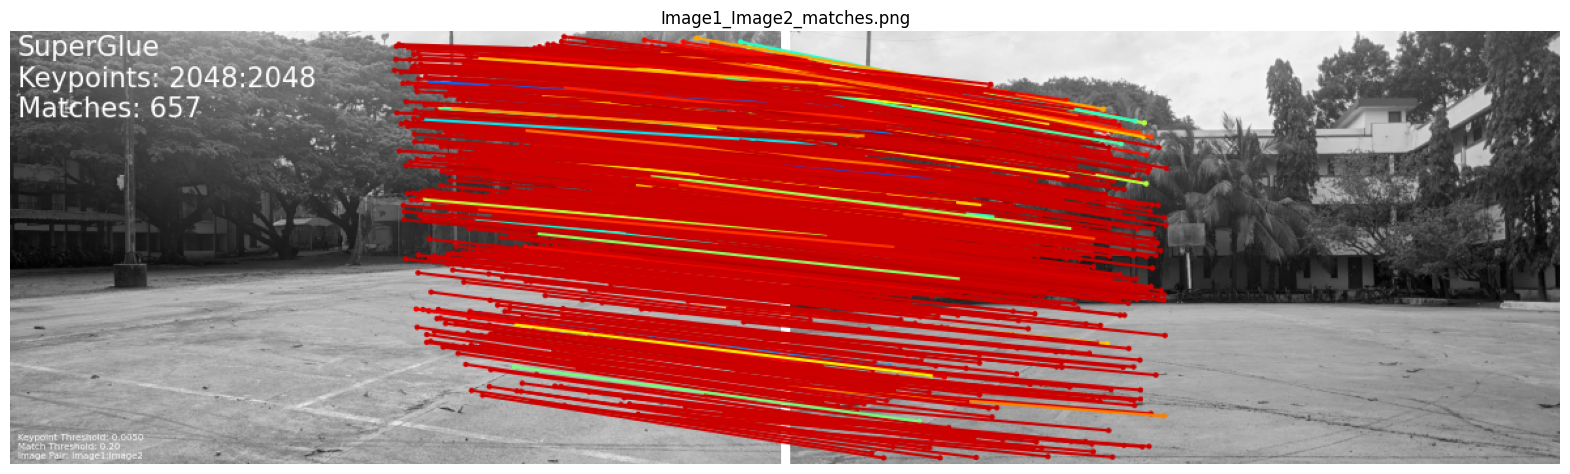

In [8]:
for file in os.listdir(output_dir):
    if file.endswith(".png"):
        img = Image.open(os.path.join(output_dir, file))

        plt.figure(figsize=(20, 10))
        plt.imshow(img)
        plt.axis("off")
        plt.title(file)
        plt.show()

In [9]:
files = [f for f in os.listdir(output_dir) if f.endswith(".npz")]

data1 = np.load(os.path.join(output_dir, files[0]))
data2 = np.load(os.path.join(output_dir, files[1]))

In [10]:
#finding valid matches

keypoints0_1 = data1["keypoints0"]
keypoints1_1 = data1["keypoints1"]
matches_1 = data1["matches"]
match_confidence_1 = data1["match_confidence"]
valid_matches_1 = matches_1 > -1 #meaning there actually is a match
good_matches_1 = valid_matches_1 & (match_confidence_1 > 0.75) #meaning match confidence is more than 0.75.

print("looking at matches between images 1,2")
print("Keypoints in image 0:", len(keypoints0_1))
print("Keypoints in image 1:", len(keypoints1_1))
print("Valid matches:", valid_matches_1.sum())
print("good matches:", good_matches_1.sum())

keypoints0_2 = data2["keypoints0"]
keypoints1_2 = data2["keypoints1"]
matches_2 = data2["matches"]
match_confidence_2 = data2["match_confidence"]
valid_matches_2 = matches_2 > -1
good_matches_2 = valid_matches_2 & (match_confidence_2 > 0.5)

print("looking at matches between images 2,3")
print("Keypoints in image 1:", len(keypoints0_2))
print("Keypoints in image 2:", len(keypoints1_2))
print("Valid matches:", valid_matches_2.sum())
print("good matches:", good_matches_2.sum())

looking at matches between images 1,2
Keypoints in image 0: 2048
Keypoints in image 1: 2048
Valid matches: 725
good matches: 708
looking at matches between images 2,3
Keypoints in image 1: 2048
Keypoints in image 2: 2048
Valid matches: 657
good matches: 644
